In [1]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
import scipy.stats as stats
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# 1. Подгрузка данных

In [2]:
tsy_tickers = [
    'DGS10', 
    'BAA10Y', # -- Baa Corporate Bond Yield Relative to Yield on 10-Year
    'AAA10Y'  # -- Aaa Corporate Bond Yield Relative to Yield on 10-Year
]
tsy_data = web.DataReader(tsy_tickers, 'fred').dropna(how='all').ffill()

In [3]:
tsy_data

,DGS10,BAA10Y,AAA10Y
DATE,,,
2020-12-01,0.92,2.28,1.31
2020-12-02,0.95,2.24,1.30
2020-12-03,0.92,2.23,1.29
2020-12-04,0.97,2.23,1.29
2020-12-07,0.94,2.22,1.32
...,...,...,...
2025-11-20,4.10,1.80,1.19
2025-11-21,4.06,1.82,1.23
2025-11-24,4.04,1.80,1.19


In [4]:
tsy_data.isna().sum()

DGS10     0
BAA10Y    0
AAA10Y    0
dtype: int64

# 2. Визуализация

In [5]:
# Compute first differences (changes)
tsy_changes = tsy_data[['DGS10', 'AAA10Y', 'BAA10Y']].diff().dropna()

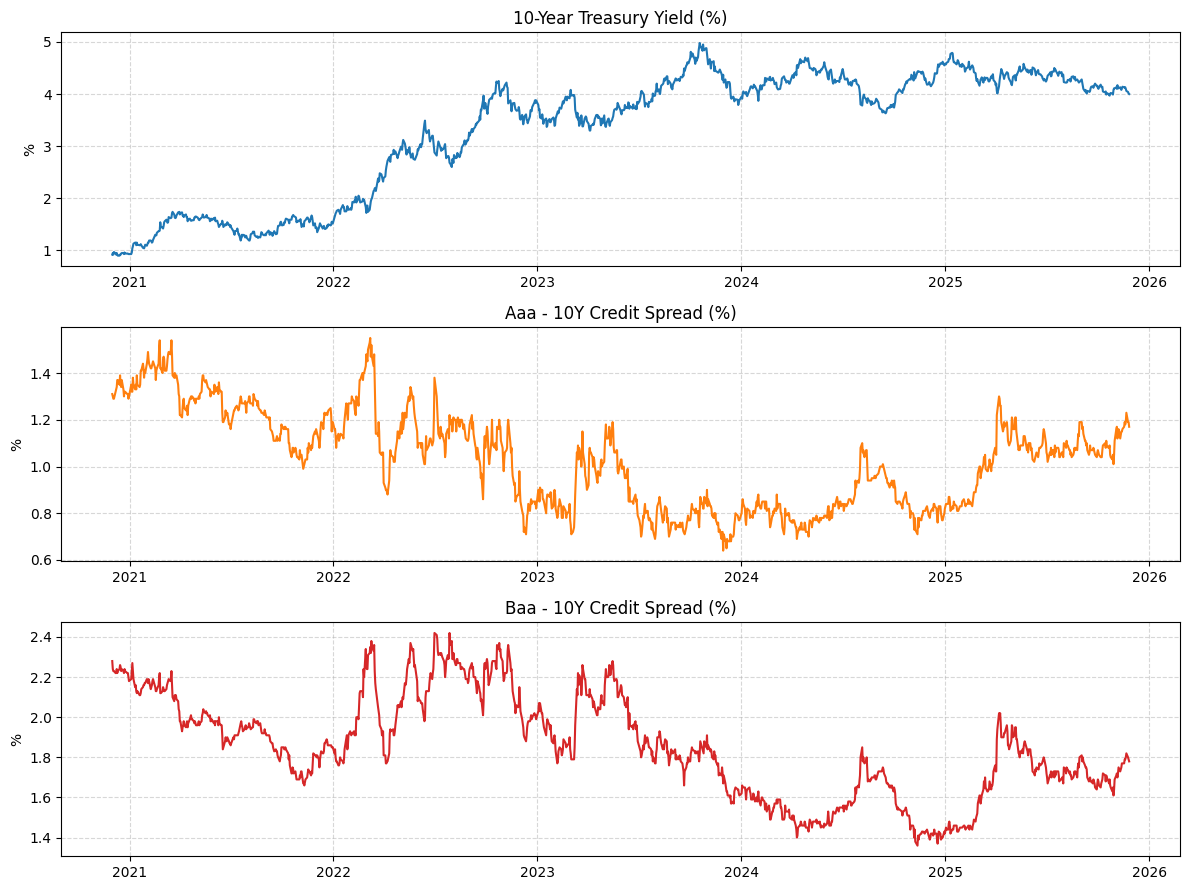

In [9]:
# 1. Time series plot (3 subplots in 1 column)
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
variables = ['DGS10', 'AAA10Y', 'BAA10Y']
titles = ['10-Year Treasury Yield (%)', 'Aaa - 10Y Credit Spread (%)', 'Baa - 10Y Credit Spread (%)']
colors = ['tab:blue', 'tab:orange', 'tab:red']

for i, var in enumerate(variables):
    axes[i].plot(tsy_data.index, tsy_data[var], color=colors[i])
    axes[i].set_title(titles[i])
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylabel('%')
plt.tight_layout()
plt.show()

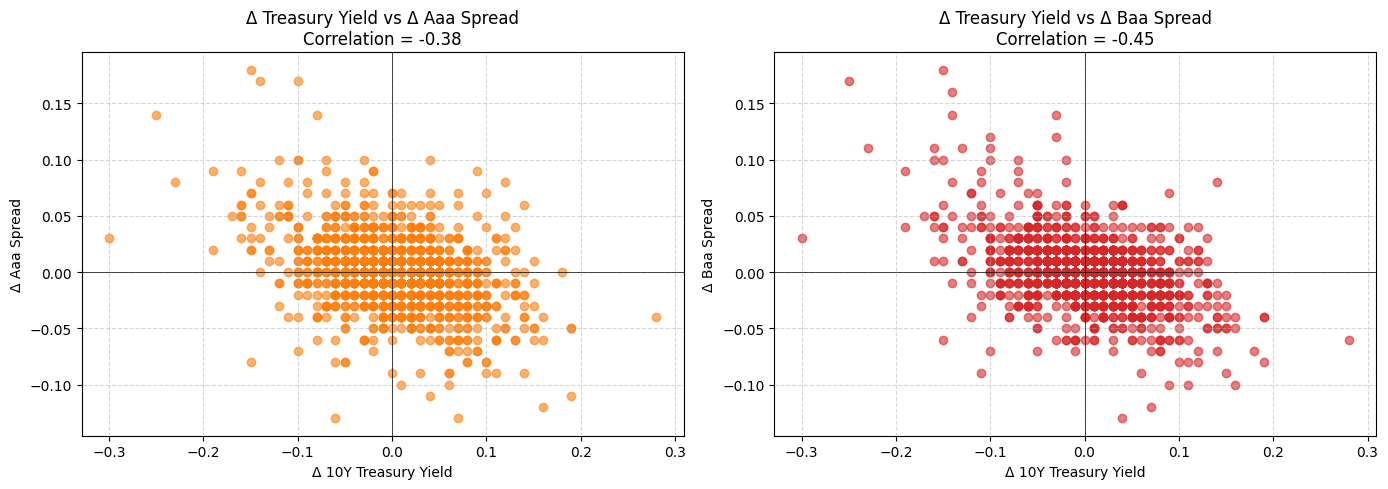

In [10]:
# 2. Scatter plots: changes in Treasury yield vs changes in spreads
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aaa
corr_aaa = tsy_changes['DGS10'].corr(tsy_changes['AAA10Y'])
axes[0].scatter(tsy_changes['DGS10'], tsy_changes['AAA10Y'], alpha=0.6, color='tab:orange')
axes[0].set_xlabel('Δ 10Y Treasury Yield')
axes[0].set_ylabel('Δ Aaa Spread')
axes[0].set_title(f'Δ Treasury Yield vs Δ Aaa Spread\nCorrelation = {corr_aaa:.2f}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Baa
corr_baa = tsy_changes['DGS10'].corr(tsy_changes['BAA10Y'])
axes[1].scatter(tsy_changes['DGS10'], tsy_changes['BAA10Y'], alpha=0.6, color='tab:red')
axes[1].set_xlabel('Δ 10Y Treasury Yield')
axes[1].set_ylabel('Δ Baa Spread')
axes[1].set_title(f'Δ Treasury Yield vs Δ Baa Spread\nCorrelation = {corr_baa:.2f}')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

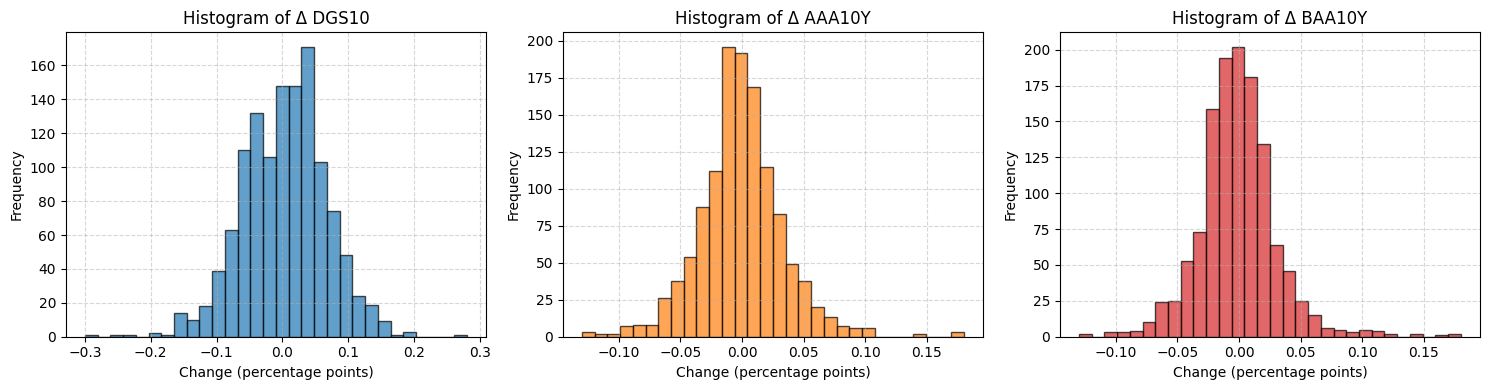

In [11]:
# 3. Histograms of changes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, var in enumerate(variables):
    axes[i].hist(tsy_changes[var], bins=30, color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Histogram of Δ {var}')
    axes[i].set_xlabel('Change (percentage points)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Проверка нормальности
## 3.1 Тест Шапиро-Уилка на нормальность

In [12]:

print("=== Normality Tests (Null Hypothesis: Data is Normally Distributed) ===")
for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    data = tsy_changes[var].dropna()
    
    stat_sw, p_sw = shapiro(data)
    print(f"\n{var}:")
    print(f"  Shapiro-Wilk p-value = {p_sw:.4f} → {'Fail to reject H0' if p_sw > 0.05 else 'Reject H0 (not normal)'}")
    

=== Normality Tests (Null Hypothesis: Data is Normally Distributed) ===

DGS10:
  Shapiro-Wilk p-value = 0.0000 → Reject H0 (not normal)

AAA10Y:
  Shapiro-Wilk p-value = 0.0000 → Reject H0 (not normal)

BAA10Y:
  Shapiro-Wilk p-value = 0.0000 → Reject H0 (not normal)


Тест отвергает гипотезу о том, что данные распределены нормально.

## 3.2 Q-Q Plot (против Нормального распределения)

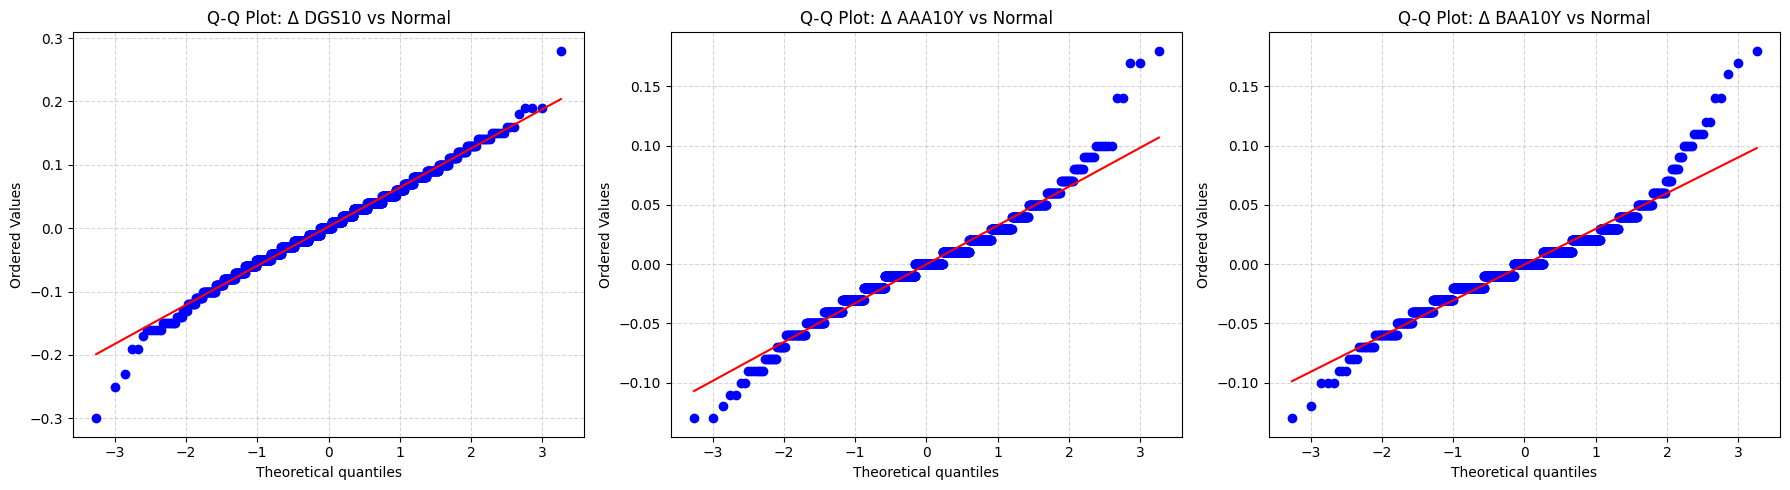

In [13]:
# Q-Q plots against normal distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
    data = tsy_changes[var].dropna()
    
    # Create Q-Q plot
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: Δ {var} vs Normal')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Q-Q графики подтверждают то, что для данных в нашей задаче нормальное распределение не является подходящим

# 4. Q-Q Plot (против распределения Стьдента)

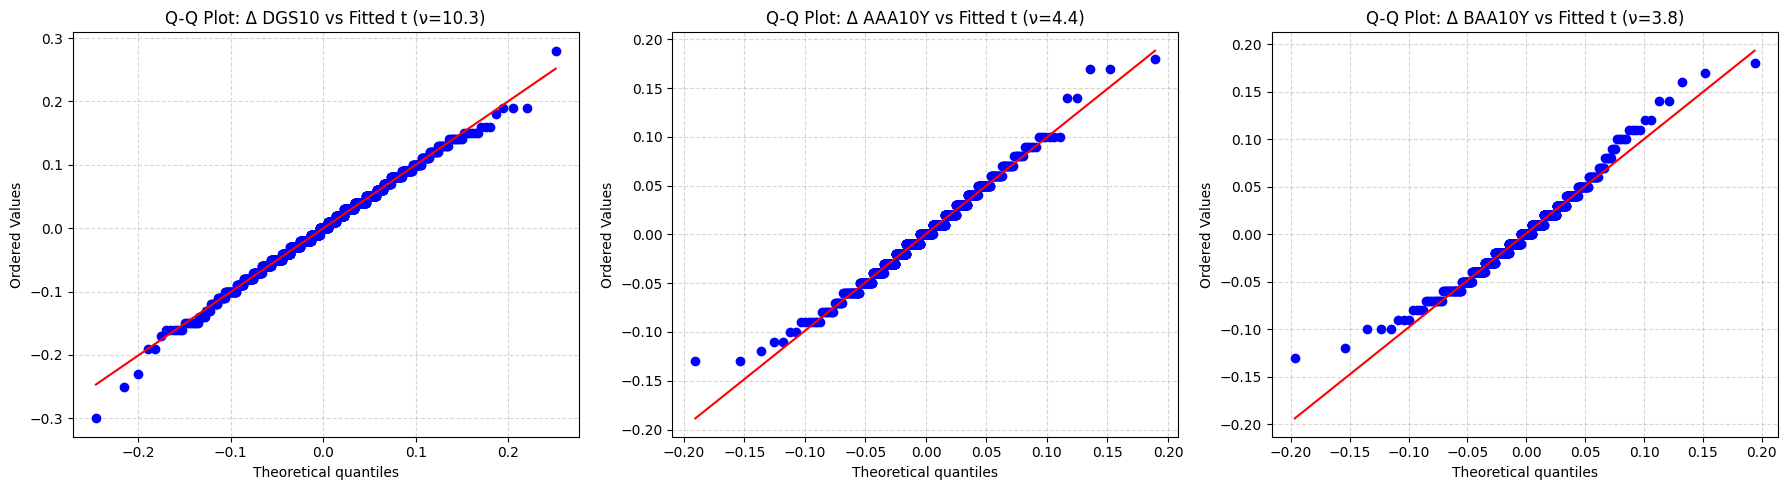

In [14]:
# Q-Q plots against fitted t-distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
    data = tsy_changes[var].dropna()
    
    # Fit t-distribution: estimates (df, loc, scale)
    df, loc, scale = stats.t.fit(data)
    
    # Create Q-Q plot against fitted t
    stats.probplot(data, dist=stats.t, sparams=(df, loc, scale), plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: Δ {var} vs Fitted t (ν={df:.1f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Q-Q графики относительно распределения стьюдента показывают, что использование этого распределения более целесообразно в этой задаче, в сравнении с нормальным распределением.

# 5. Построение модели GARCH(1,1)-t

In [19]:
results_dict = {}
std_resids = {}

for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    y = tsy_changes[var].dropna()
    
    model = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1, dist='t', rescale=False)
    res = model.fit(disp='off')
    
    results_dict[var] = res
    std_resids[var] = res.resid / res.conditional_volatility

print("\n=== GARCH(1,1)-t Model Parameters ===")
summary_data = []
for var, res in results_dict.items():
    params = res.params
    omega = params['omega']
    alpha = params['alpha[1]']
    beta = params['beta[1]']
    nu = params['nu']
    persist = alpha + beta

    long_run_vol = (omega / (1 - persist))**0.5 if persist < 1 else float('nan')
    summary_data.append({
        'Variable': var,
        'ω (long-run var)': f"{omega:.2e}",
        'α (shock)': f"{alpha:.3f}",
        'β (persistence)': f"{beta:.3f}",
        'α+β': f"{persist:.3f}",
        'ν (tail thickness)': f"{nu:.2f}",
        'Long-run vol (bps, annualized)': f"{long_run_vol*100*np.sqrt(252):.2f} bps" 
    })

summary_df = pd.DataFrame(summary_data)
summary_df


=== GARCH(1,1)-t Model Parameters ===


,Variable,ω (long-run var),α (shock),β (persistence),α+β,ν (tail thickness),"Long-run vol (bps, annualized)"
0,DGS10,6.03e-05,0.045,0.940,0.984,22.77,98.34 bps
1,AAA10Y,2.75e-05,0.089,0.889,0.978,6.80,56.48 bps
2,BAA10Y,1.95e-05,0.090,0.890,0.980,6.89,49.41 bps


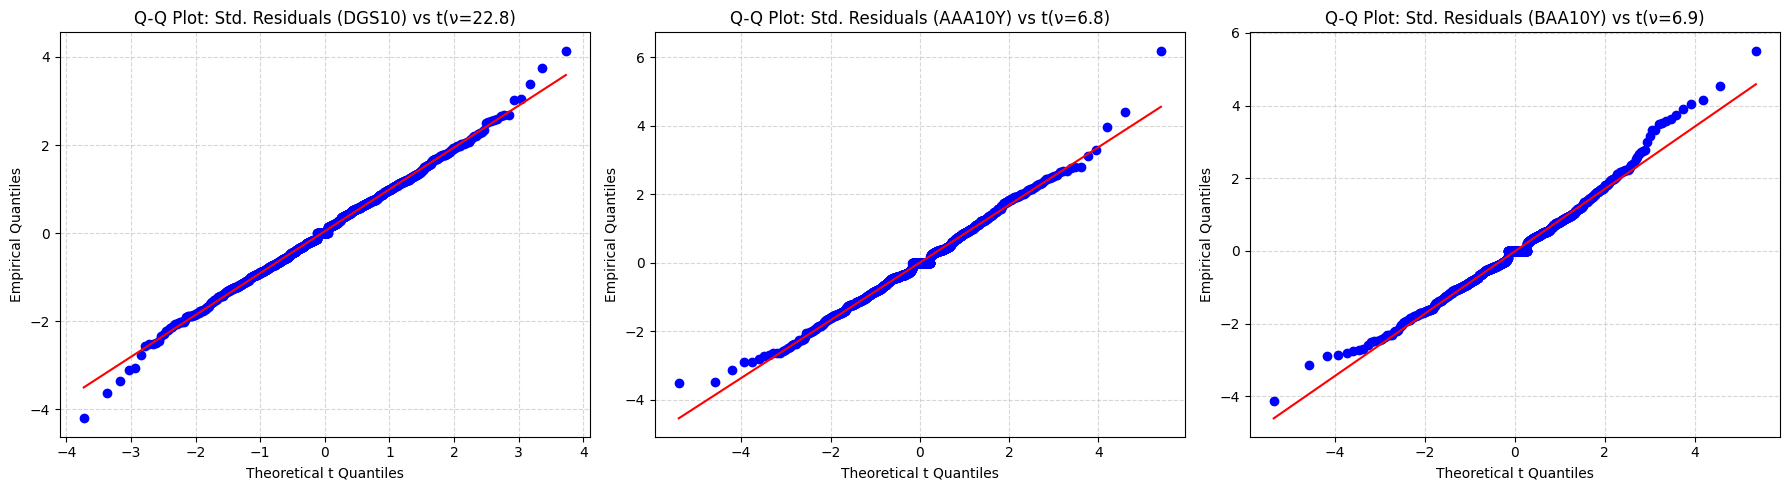

In [16]:
# Q-Q plots of standardized residuals vs. theoretical t (with model-estimated ν)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
    # Get standardized residuals and estimated ν from the fitted model
    std_resid = std_resids[var]
    nu = results_dict[var].params['nu']
    
    # Theoretical t-distribution for Q-Q: standard t with df=nu (no location/scale—already standardized)
    stats.probplot(std_resid, dist=stats.t, sparams=(nu,), plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: Std. Residuals ({var}) vs t(ν={nu:.1f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylabel('Empirical Quantiles')
    axes[i].set_xlabel('Theoretical t Quantiles')

plt.tight_layout()
plt.show()

## 5.2 Тест Льюнга-Бокса для проверки автокорреляции
Тест для проверки эффекта авторегрессионной условной гетероскедастичности (ARCH)

In [17]:
print("=== Ljung-Box Test on Squared Changes (H₀: No ARCH effects) ===")
for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    y = tsy_changes[var].dropna()

    lb_result = acorr_ljungbox(y**2, lags=1, return_df=True)
    pval = lb_result['lb_pvalue'].iloc[-1]  # p-value at lag 10
    print(f"{var}: Ljung-Box p-value (lag 10) = {pval:.4f} → {'ARCH effects present' if pval < 0.05 else 'No ARCH'}")


=== Ljung-Box Test on Squared Changes (H₀: No ARCH effects) ===
DGS10: Ljung-Box p-value (lag 10) = 0.0094 → ARCH effects present
AAA10Y: Ljung-Box p-value (lag 10) = 0.0000 → ARCH effects present
BAA10Y: Ljung-Box p-value (lag 10) = 0.0000 → ARCH effects present


Тест подверждает наличие автокорреляций для всех трех переменных. Следовательно, использование GARCH модели обоснованно и целесообразно.